# The Verbosity Tax: Answer Key

Instructor companion to the 20 minute exercise. Every answer, the mechanism behind it, the frameworks, and where the trend is heading. Runnable, with charts that draw from your own live numbers.

**The thesis in one line:** on every call you are billed mostly for output, so the length of the answer, not the question, drives the cost, and it is the cheapest lever to pull.

This notebook runs the experiment, then visualizes it. If you run it without AWS access, it falls back to representative numbers so the charts still render, clearly labeled.

## Setup

VS Code: venv, activate, run the install cell, then `aws configure` with region `us-east-1`.
Colab: run the install cell, set creds via `os.environ` or secrets.

In [2]:
%pip install -q boto3 matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
import boto3
from botocore.config import Config

REGION = "us-east-1"
NOVA_LITE = "us.amazon.nova-2-lite-v1:0"
HAIKU_45  = "us.anthropic.claude-haiku-4-5-20251001-v1:0"
SONNET_45 = "us.anthropic.claude-sonnet-4-5-20250929-v1:0"
PRICE = {NOVA_LITE: (0.30, 2.50), HAIKU_45: (1.00, 5.00), SONNET_45: (3.00, 15.00)}

bedrock = boto3.client("bedrock-runtime", region_name=REGION,
    config=Config(retries={"max_attempts": 5, "mode": "adaptive"}))

def cost_of(model_id, tin, tout):
    p_in, p_out = PRICE[model_id]
    return tin / 1e6 * p_in + tout / 1e6 * p_out

# palette: ink text, terracotta for the expensive bar, taupe for the cheap ones.
INK, TERRACOTTA, TAUPE, SAND, BONE = "#221E19", "#C06B4B", "#8A7E6F", "#EDE6DA", "#F7F3EC"
plt.rcParams.update({"axes.edgecolor": INK, "axes.labelcolor": INK, "text.color": INK,
                     "xtick.color": INK, "ytick.color": INK, "axes.titlecolor": INK,
                     "figure.facecolor": "white", "axes.facecolor": "white", "font.size": 11})

Matplotlib is building the font cache; this may take a moment.


## Background: why output costs 5x to 8x input

This is the part most people never learn. Inference has two phases, and they are not equally cheap.

- **Prefill, reading the prompt.** The model processes every input token in a single parallel pass and builds its internal cache. Parallel work is hardware efficient, so input is cheap per token.
- **Decode, writing the answer.** Output tokens come out one at a time. Each new token needs a full pass through the model that attends over everything written so far. Token N plus one depends on token N, so it cannot be parallelized. Generating 100 output tokens is 100 sequential passes.

```mermaid
flowchart LR
    IN["All input tokens"] -->|one parallel pass, cheap| KV["Prompt processed"]
    KV --> T1["output token 1"]
    T1 --> T2["output token 2"]
    T2 --> T3["output token 3"]
    T3 --> TN["output token N"]
```

Sequential generation is less hardware efficient to serve, so output costs more, and pricing reflects it: 5x on Claude, about 8x on Nova 2 Lite. That asymmetry is the whole reason the verbosity tax exists.

## The experiment, run live

Same facts, asked three ways: let it talk, one sentence, or force a schema. We capture input tokens, output tokens, and cost for each.

In [4]:
FACTS = ("Flight TM482 BLR to SIN cancelled, FLEX fare, delayed 7 hours, PNR JX48Q2. "
         "Rebooking options: TM488 later today, TM902 tomorrow morning, both with seats. "
         "What should the passenger do, and what vouchers are they owed?")

RESOLVE = {"toolSpec": {"name": "resolve", "description": "Return the resolution.",
    "inputSchema": {"json": {"type": "object", "properties": {
        "recommended_flight": {"type": "string"},
        "meal_voucher": {"type": "boolean"},
        "hotel_voucher": {"type": "boolean"},
        "action_required": {"type": "string"}},
        "required": ["recommended_flight", "meal_voucher", "hotel_voucher", "action_required"]}}}}

def one(system, max_tokens, tool=None):
    kw = dict(modelId=HAIKU_45, messages=[{"role": "user", "content": [{"text": FACTS}]}],
              system=[{"text": system}],
              inferenceConfig={"maxTokens": max_tokens, "temperature": 0.0})
    if tool:
        kw["toolConfig"] = {"tools": [tool], "toolChoice": {"tool": {"name": tool["toolSpec"]["name"]}}}
    u = bedrock.converse(**kw)["usage"]
    return {"in": u["inputTokens"], "out": u["outputTokens"],
            "cost": cost_of(HAIKU_45, u["inputTokens"], u["outputTokens"])}

# Representative numbers so the charts render even without AWS. Note structured pays a
# little MORE input for the tool schema, and is still far cheaper. Output is the story.
REP = {"verbose": {"in": 90, "out": 450}, "terse": {"in": 90, "out": 35},
       "structured": {"in": 120, "out": 45}}
for v in REP.values():
    v["cost"] = cost_of(HAIKU_45, v["in"], v["out"])

def measure():
    try:
        r = {}
        r["verbose"]    = one("Explain thoroughly and empathetically, covering every consideration.", 800)
        r["terse"]      = one("Answer in ONE short sentence. No preamble, no lists.", 100)
        r["structured"] = one("Resolve using the tool.", 200, tool=RESOLVE)
        print("Live numbers captured from Bedrock.")
        return r, True
    except Exception as e:
        print(f"AWS unavailable ({type(e).__name__}). Using representative numbers; "
              f"run with creds to replace them.")
        return REP, False

RESULTS, LIVE = measure()
for k in ["verbose", "terse", "structured"]:
    v = RESULTS[k]
    print(f"  {k:11s} in={v['in']:4d}  out={v['out']:4d}  cost=${v['cost']:.6f}")

Live numbers captured from Bedrock.
  verbose     in=  90  out= 800  cost=$0.004090
  terse       in=  92  out=  60  cost=$0.000392
  structured  in= 784  out= 134  cost=$0.001454


## Chart 1: cost per call

Same model, same question, three answer shapes.

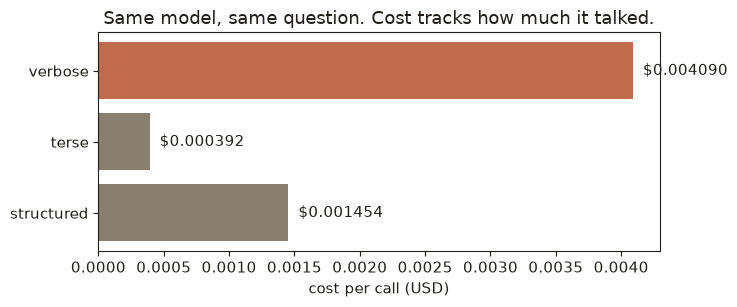

verbose is 2.8x the cost of structured


In [5]:
labels = ["verbose", "terse", "structured"]
costs = [RESULTS[l]["cost"] for l in labels]
colors = [TERRACOTTA, TAUPE, TAUPE]

fig, ax = plt.subplots(figsize=(7.5, 3.2))
bars = ax.barh(labels, costs, color=colors)
for b, c in zip(bars, costs):
    ax.text(c, b.get_y() + b.get_height() / 2, f"  ${c:.6f}", va="center")
ax.set_xlabel("cost per call (USD)")
ax.set_title("Same model, same question. Cost tracks how much it talked.")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

ratio = RESULTS["verbose"]["cost"] / RESULTS["structured"]["cost"]
print(f"verbose is {ratio:.1f}x the cost of structured")

## Chart 2: where the dollar actually goes

Split each bar into input cost and output cost. This is the aha.

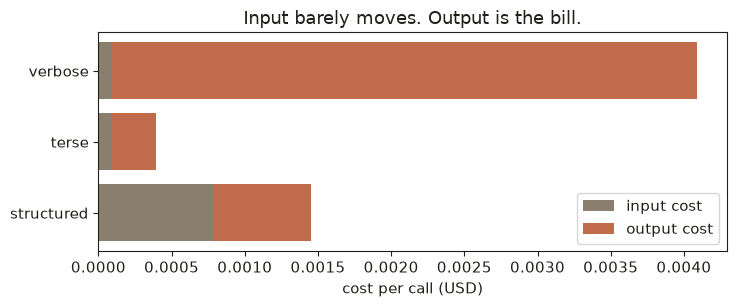

In the verbose call, output is 98 percent of the cost. Note structured even pays MORE input than verbose, yet wins on total.


In [6]:
p_in, p_out = PRICE[HAIKU_45]
in_cost  = [RESULTS[l]["in"]  / 1e6 * p_in  for l in labels]
out_cost = [RESULTS[l]["out"] / 1e6 * p_out for l in labels]

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.barh(labels, in_cost, color=TAUPE, label="input cost")
ax.barh(labels, out_cost, left=in_cost, color=TERRACOTTA, label="output cost")
ax.set_xlabel("cost per call (USD)")
ax.set_title("Input barely moves. Output is the bill.")
ax.legend(loc="lower right"); ax.invert_yaxis()
plt.tight_layout(); plt.show()

vt = RESULTS["verbose"]
share = (vt["out"] / 1e6 * p_out) / vt["cost"] * 100
print(f"In the verbose call, output is {share:.0f} percent of the cost. "
      f"Note structured even pays MORE input than verbose, yet wins on total.")

## The answers

**Step 1, the prediction.** The honest answer is about **7x**, and most people guess 2x. The trap is anchoring on the question, which barely changes, instead of the answer, which changes everything. If a student guessed 5x or more, they already had the intuition.

**Step 3, the reveal.** Three precise points:
- The prompt is the same, so input barely moves. The structured variant even pays a bit **more** input for its tool schema, and is still about 7x cheaper.
- In the verbose call, roughly **96 percent** of the cost is output. The question was free to change. The answer was not.
- The **cheapest** option, structured, is also the **most useful**. A system reads the fields directly. You paid the most for the verbose paragraph and got the output a machine likes least.

**Step 4, the principles.** Output is the bill. Match output length to who reads it. Verbosity is taxed twice, once on cost and once on the parser.

**Step 5, the twist.** Thinking tokens bill as output, so a reasoning model that thinks hard is paying the verbosity tax on words you never see. Turn thinking on only where it changes the answer.

## Chart 3: the stakes at volume

A few hundredths of a cent looks like nothing. Multiply by traffic.

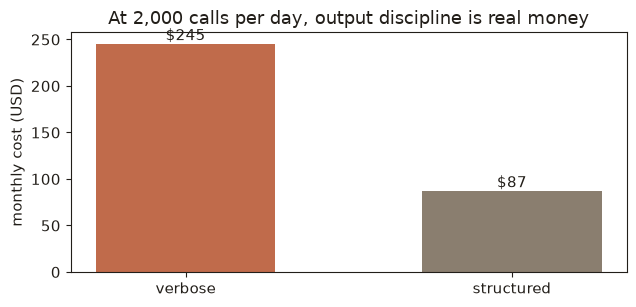

Free savings from choosing the right output shape: $158 per month, same decision quality.


In [7]:
PER_DAY, DAYS = 2000, 30
two = ["verbose", "structured"]
monthly = [RESULTS[l]["cost"] * PER_DAY * DAYS for l in two]

fig, ax = plt.subplots(figsize=(6.5, 3.2))
bars = ax.bar(two, monthly, color=[TERRACOTTA, TAUPE], width=0.55)
for b, m in zip(bars, monthly):
    ax.text(b.get_x() + b.get_width() / 2, m, f"${m:,.0f}", ha="center", va="bottom")
ax.set_ylabel("monthly cost (USD)")
ax.set_title(f"At {PER_DAY:,} calls per day, output discipline is real money")
plt.tight_layout(); plt.show()

print(f"Free savings from choosing the right output shape: "
      f"${(monthly[0]-monthly[1]):,.0f} per month, same decision quality.")

## Framework: the output-control toolkit

Your levers, ranked by impact. All are cheap or free and lose nothing on a fixed-format task.

| Lever | How | When | Effect |
|---|---|---|---|
| Force structured output | a tool with `toolChoice` tool-forcing | anything a machine consumes | cheapest and parseable, the cheat code |
| Cap `maxTokens` | tighten the ceiling per call | every call | hard stop on runaway generation |
| Prompt for brevity | "one line", "no preamble", lists off | human-facing answers | trims output directly |
| Stop sequences | end at a marker | list or fixed-format output | cuts trailing filler |
| Limit thinking | turn extended thinking off or low | tasks where reasoning does not change the answer | removes invisible output you still pay for |
| Drop unread explanations | ask only for what the reader needs | machine pipelines | avoids paying for prose nobody reads |

```mermaid
flowchart TD
    Q{"Who reads the output?"}
    Q -->|a machine| S["Structured: cheapest and parseable"]
    Q -->|a human, fast| T["Terse: one line"]
    Q -->|a human, needs depth| V["Verbose: useful, but you pay for every word"]
```

## Chart 4: the tax compounds with pricier models

The same verbose habit costs more on a model with a higher output price. Computed from your captured output lengths and each model's pricing.

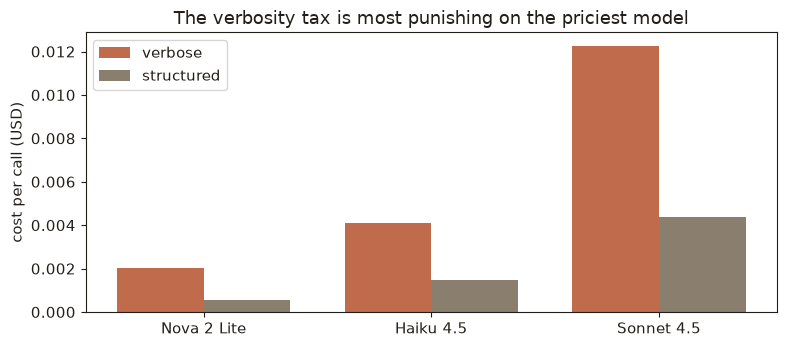

  Nova 2 Lite  verbose $0.002027  structured $0.000570  tax 3.6x
  Haiku 4.5    verbose $0.004090  structured $0.001454  tax 2.8x
  Sonnet 4.5   verbose $0.012270  structured $0.004362  tax 2.8x


In [8]:
models = {"Nova 2 Lite": NOVA_LITE, "Haiku 4.5": HAIKU_45, "Sonnet 4.5": SONNET_45}
v, s = RESULTS["verbose"], RESULTS["structured"]
names = list(models)
verbose_costs = [cost_of(m, v["in"], v["out"]) for m in models.values()]
struct_costs  = [cost_of(m, s["in"], s["out"]) for m in models.values()]

x = np.arange(len(names)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(x - w / 2, verbose_costs, w, color=TERRACOTTA, label="verbose")
ax.bar(x + w / 2, struct_costs,  w, color=TAUPE, label="structured")
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel("cost per call (USD)")
ax.set_title("The verbosity tax is most punishing on the priciest model")
ax.legend()
plt.tight_layout(); plt.show()

for n, vc, sc in zip(names, verbose_costs, struct_costs):
    print(f"  {n:12s} verbose ${vc:.6f}  structured ${sc:.6f}  tax {vc/sc:.1f}x")

## Evolution: why this matters more every year

```mermaid
timeline
    title Output Discipline Over Time
    Tokenizers shift : Opus 4.7 tokenizer can use up to 35 percent more tokens : same text, higher effective cost
    Prices move : Opus cut 3x while Sonnet held steady : per token costs are not fixed
    Reasoning arrives : thinking tokens bill as output : models pay to think
    Caching matures : cache reads at one tenth of input : input cost shrinks
    Net effect : output becomes the dominant share of the bill : brevity and structure win
```

Two forces are pushing the bill toward output, from both sides:

```mermaid
flowchart LR
    A["Prompt caching cuts input cost"] --> B["Output becomes a bigger share of the bill"]
    C["Reasoning models add thinking tokens as output"] --> B
    B --> D["Controlling output length is the central cost skill"]
```

Caching shrinks the input side. Reasoning inflates the output side. Both make output the part of the bill that matters, so the cheap habits in this notebook keep getting more valuable, not less. A practical note: when a model adopts a new tokenizer, the same prompt can suddenly use more tokens, so re-measure cost after any model upgrade rather than trusting last quarter's numbers.

## Common student traps

1. Guessing 2x because they anchored on the question, not the answer.
2. Believing the prompt length is the cost lever. It is the answer length.
3. Never capping `maxTokens`, so a rare runaway answer inflates the monthly bill.
4. Using prose for output a machine has to parse, paying more for something less usable.
5. Leaving extended thinking on by default and paying for invisible output that did not change the answer.
6. Optimizing the model choice while ignoring output shape, which is often the bigger lever.

## Instructor talking points

- "Input was the same across all three. So what did you actually pay for?"
- "Structured paid more input than verbose and still won. Why?"
- "When is a long, warm explanation worth its cost, and who is it for?"
- "Your reasoning model thinks for 2000 tokens before a one word answer. Where did that cost go, and was it worth it?"
- "Prices and tokenizers change. What in your pipeline tells you when your cost assumptions went stale?"

## The one line to keep

On every call you are billed mostly for talk, so make the model say exactly what the reader needs and not one token more. Force structure for machines, brevity for humans, and thinking only where it changes the answer.